In [1]:
from Bio import SeqIO
import matplotlib.pyplot as plt

In [2]:
def get_polyAT_lengths(fasta_file):
    lengths = []
    for record in SeqIO.parse(fasta_file, "fasta"):
        seq = str(record.seq).upper()

        current_len = 0
        current_base = None

        for base in seq:
            if base in ["A", "T"]:
                if base == current_base:
                    current_len += 1
                else:
                    if current_len > 0:
                        lengths.append(current_len)
                    current_len = 1
                    current_base = base
            else:
                if current_len > 0:
                    lengths.append(current_len)
                    current_len = 0
                    current_base = None

        # catch the last run
        if current_len > 0:
            lengths.append(current_len)

    return lengths

In [3]:
# Get distributions
orig_lengths = get_polyAT_lengths("/scratch1/smaruj/CTCF_elimination/gamma_300.0/original_sequences_2168bp.fasta")
opt_lengths  = get_polyAT_lengths("/scratch1/smaruj/CTCF_elimination/gamma_300.0/optimized_sequences_2168bp.fasta")

In [8]:
max(orig_lengths), max(opt_lengths)

(31, 21)

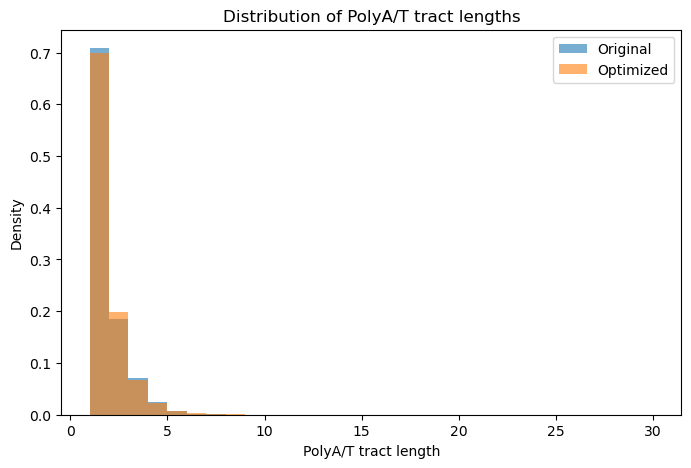

In [9]:
# Plot histograms
plt.figure(figsize=(8,5))
plt.hist(orig_lengths, bins=range(1, 31), alpha=0.6, label="Original", density=True)
plt.hist(opt_lengths, bins=range(1, 31), alpha=0.6, label="Optimized", density=True)
plt.xlabel("PolyA/T tract length")
plt.ylabel("Density")
plt.title("Distribution of PolyA/T tract lengths")
plt.legend()
plt.show()